In [1]:
# downloading 
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("xiaose/cityscapes", output_dir='/home/hxastur/vscode-projects/autonomous-driving/data')

# print("Path to dataset files:", path)

# path = kagglehub.model_download("metaresearch/dinov2/pyTorch/base", output_dir='/home/hxastur/vscode-projects/autonomous-driving/model')

# print("Path to model files:", path)

In [1]:
import numpy as np
import pandas as pd
from transformers import AutoImageProcessor, AutoModel
import torch
import os
from pathlib import Path
from tqdm.notebook import tqdm

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
print('device:',device)

device: cuda


In [10]:
# Определение пути 
if Path('/kaggle/input').exists():
    model_path = '/kaggle/input/models/metaresearch/dinov2/pytorch/base/1/'
    dataset_path = '/kaggle/input/datasets/xiaose/cityscapes/Cityspaces/images'
else:
    notebook_path = Path.cwd()
    root_path = notebook_path.parent.parent 
    dataset_path = root_path / 'data' / 'Cityspaces' / 'images'
    model_path = root_path / 'model'
print(f'Model path: {model_path}\nDataset path: {dataset_path}')

Model path: /home/hxastur/vscode-projects/autonomous-driving/model
Dataset path: /home/hxastur/vscode-projects/autonomous-driving/data/Cityspaces/images


In [11]:
processor = AutoImageProcessor.from_pretrained(model_path)
model = AutoModel.from_pretrained(model_path)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [13]:
all_img = []
for dirname, _, filenames in os.walk(dataset_path):
    current_list = [f'{dirname}/{f}' for f in filenames]
    all_img.extend(current_list)
len(all_img)

3475

In [14]:
all_img[1]

'/home/hxastur/vscode-projects/autonomous-driving/data/Cityspaces/images/val/lindau/lindau_000027_000019_leftImg8bit.png'

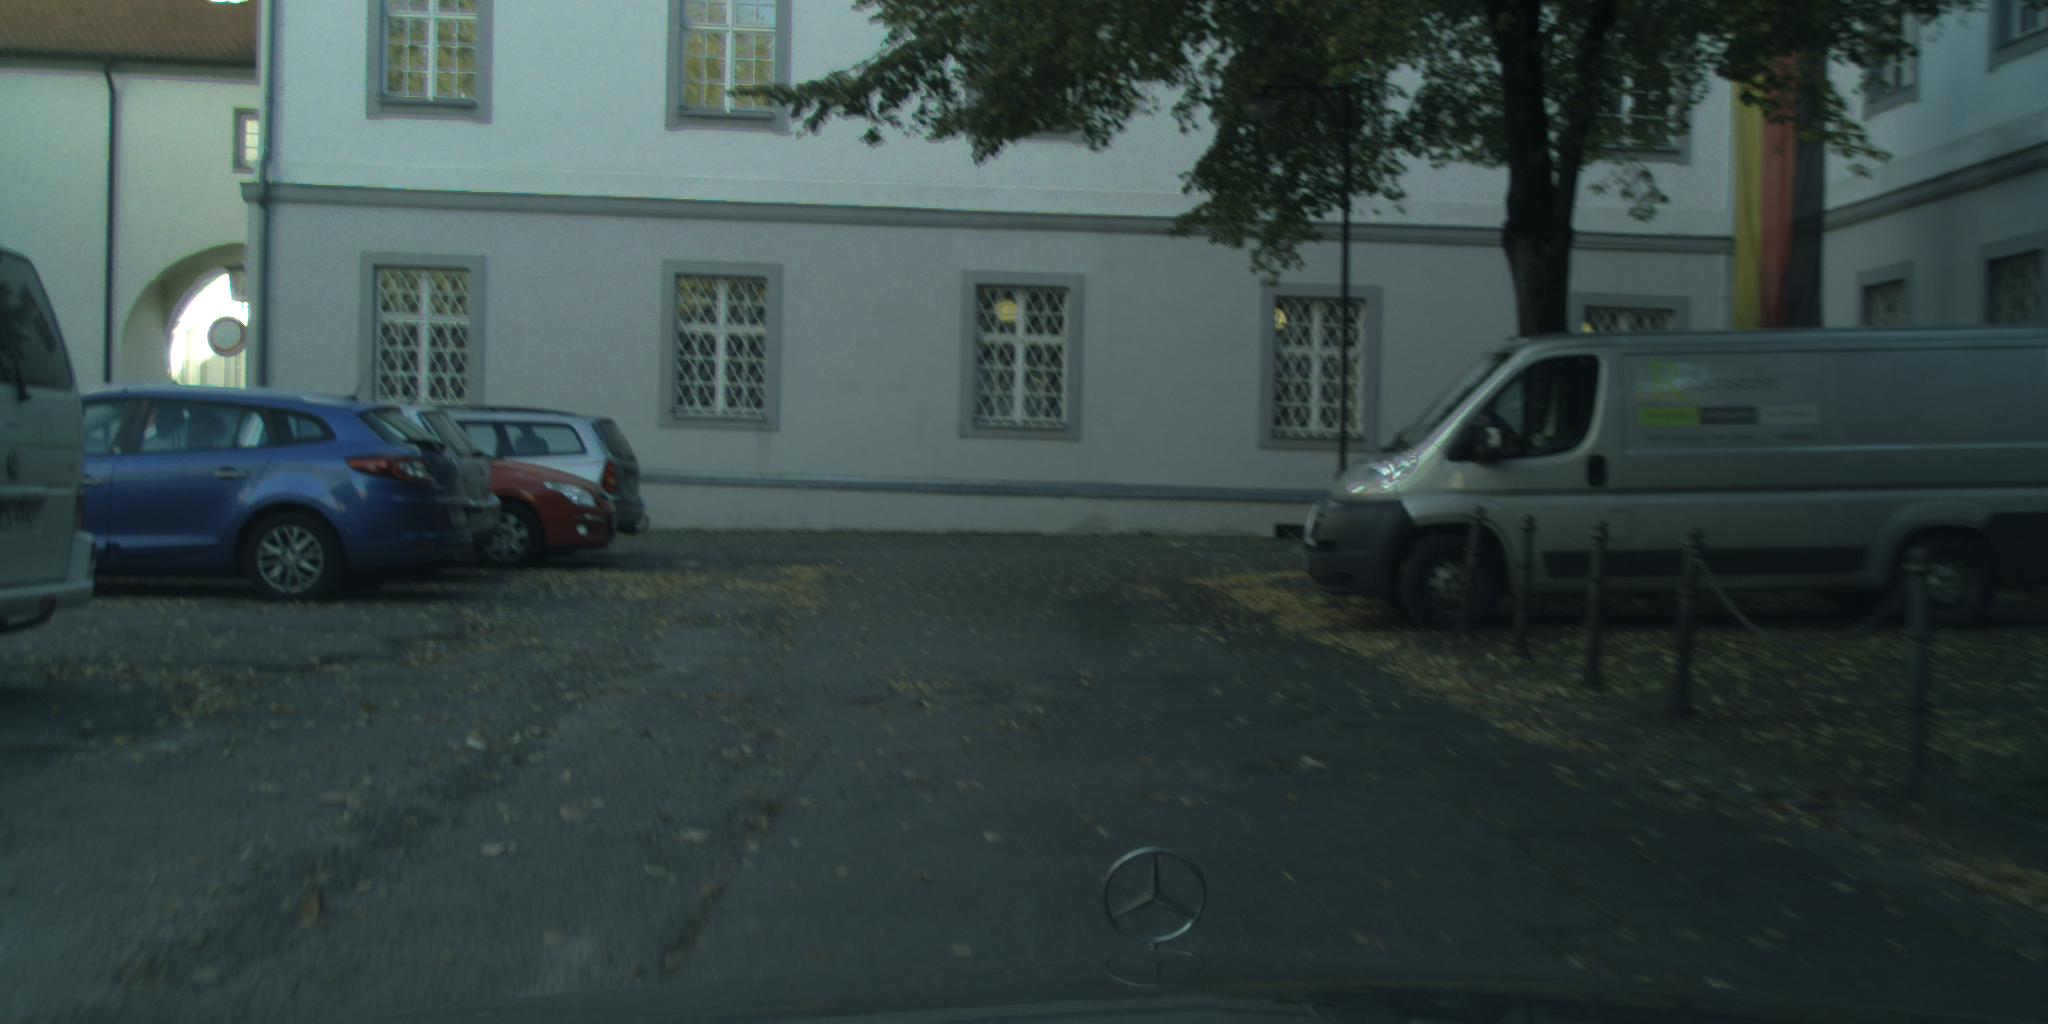

In [15]:
from PIL import Image
img_list = [Image.open(f_path) for f_path in all_img[:50]]
img_list[1]

In [16]:
inputs = processor(images=img_list[1], return_tensors="pt")
outputs = model(**inputs)
last_hidden_states = outputs.last_hidden_state
last_hidden_states.shape

torch.Size([1, 257, 768])